In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from ModelGrafo import Disciplina

### Criando Disciplinas

In [12]:
disciplinas = {}


def criar_disciplina(codigo, nome, carga=64):

    d = Disciplina(
        codigo,
        nome,
        carga
    )

    disciplinas[codigo] = d

    return d

# Cadastro das Disciplinas
XDES01 = criar_disciplina(
    "XDES01",
    "Fundamentos de Programação"
)


CTC001 = criar_disciplina(
    "CTC001",
    "Algoritmos e Estruturas de Dados I"
)


CTC002 = criar_disciplina(
    "CTC002",
    "Algoritmos e Estruturas de Dados II"
)


XDES02 = criar_disciplina(
    "XDES02",
    "Programação Orientada a Objetos"
)


XDES03 = criar_disciplina(
    "XDES03",
    "Programação Web"
)


XDES04 = criar_disciplina(
    "XDES04",
    "Engenharia de Software I"
)


SDES05 = criar_disciplina(
    "SDES05",
    "Engenharia de Software II"
)

### Adicionando os pré-requisitos

In [13]:
CTC001.adicionar_pre_requisito(XDES01)

CTC002.adicionar_pre_requisito(CTC001)


XDES02.adicionar_pre_requisito(XDES01)

XDES03.adicionar_pre_requisito(XDES02)


SDES05.adicionar_pre_requisito(XDES04)

### Criando o Grafo

In [14]:
grafo = nx.DiGraph()


for disciplina in disciplinas.values():

    grafo.add_node(disciplina)



for disciplina in disciplinas.values():

    for requisito in disciplina.pre_requisitos:

        grafo.add_edge(
            requisito,
            disciplina
        )

### Histórico do aluno

In [15]:
historico = {

    "XDES01": "CONCLUIDA",

    "XDES04": "CONCLUIDA",

    "CTC001": "REPROVADA"

}

### Atualizar Grafo

In [16]:
for disciplina in disciplinas.values():

    if disciplina.codigo in historico:

        disciplina.estado = historico[disciplina.codigo]

### Encontrar Disciplinas disponíveis

In [17]:
def encontrar_disponiveis():

    disponiveis = []


    for disciplina in disciplinas.values():


        if disciplina.estado != "NAO_CURSO":

            continue


        liberada = True


        for requisito in disciplina.pre_requisitos:


            if requisito.estado != "CONCLUIDA":

                liberada = False



        if liberada:

            disciplina.estado = "DISPONIVEL"

            disponiveis.append(disciplina)


    return disponiveis

### Ordenação Topológica

In [20]:
ordem = nx.topological_sort(grafo)


for disciplina in ordem:

    print(
        f"{disciplina.codigo} - {disciplina.nome}"
    )

XDES01 - Fundamentos de Programação
XDES04 - Engenharia de Software I
CTC001 - Algoritmos e Estruturas de Dados I
XDES02 - Programação Orientada a Objetos
SDES05 - Engenharia de Software II
CTC002 - Algoritmos e Estruturas de Dados II
XDES03 - Programação Web


### Mostrar Grafo

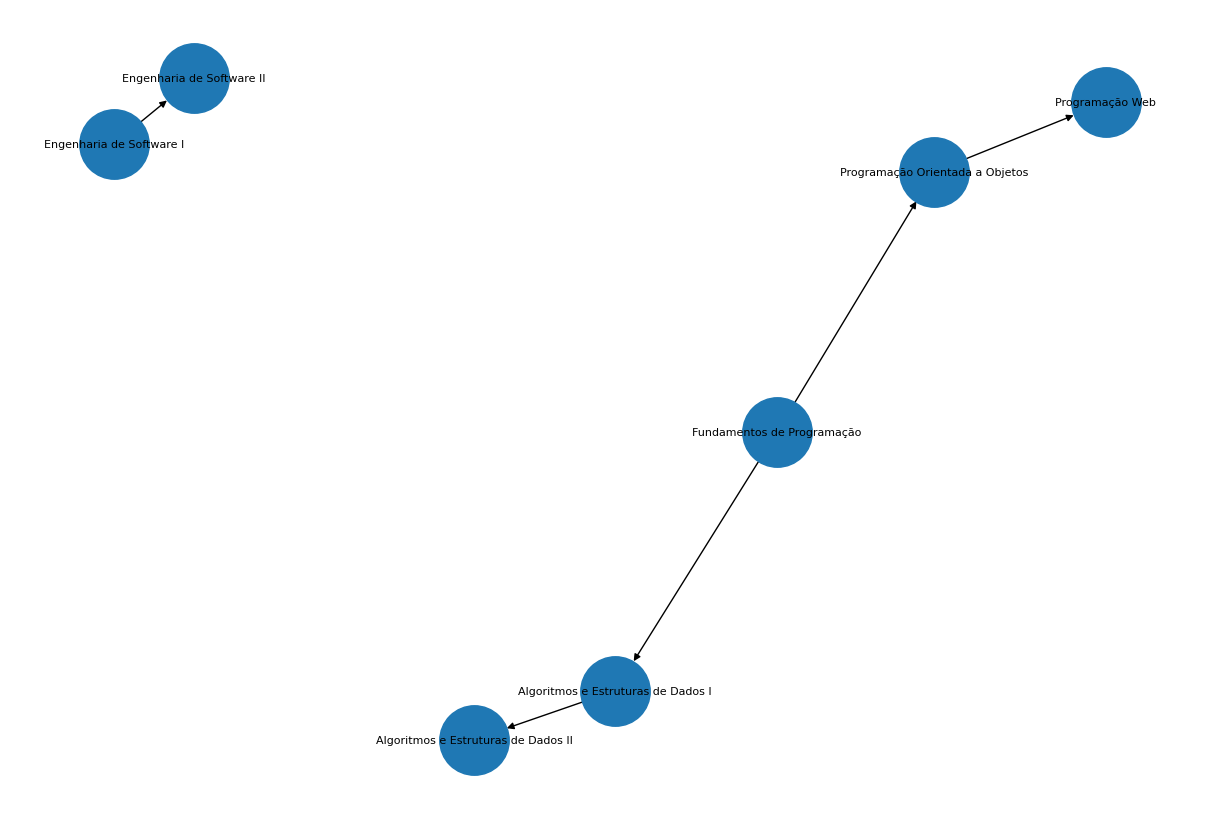

In [22]:
plt.figure(figsize=(12,8))


pos = nx.spring_layout(grafo)


labels = {

    disciplina: disciplina.nome

    for disciplina in grafo.nodes

}


nx.draw(
    grafo,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2500,
    font_size=8
)


plt.show()